# Spatio-Temporal GCN for Traffic Prediction

![Traffic](./PredictingTraffic.png)

This project explores how to implement a spatio-temporal Graph Convolutional Network (GCN) to predict short-term traffic at each sensor node in a 10×10 grid.### Learning OutcomesBy the end of this project, you will be able to:1. **Simulate & normalize** multivariate time-series data on a graph  2. **Create sliding-window data loaders** for sequence-to-one prediction  3. **Define and implement** a temporal + spatial GCN architecture in PyTorch  4. **Train** the model with proper regularization and learning-rate scheduling  5. **Evaluate** model performance (MSE) and **visualize** true vs. predicted trafficYou are only allowed to use the following libraries ```python import numpy as np, networkx as nx, matplotlib.pyplot as plt, torchimport torch.nn as nn, torch.nn.functional as F, torch.optim as optim```

In [6]:
# Make Imports here:import numpy as npimport networkx as nximport matplotlib.pyplot as pltimport torchimport torch.nn as nnimport torch.nn.functional as Fimport torch.optim as optimfrom torch.utils.data import TensorDataset, DataLoader

### Dataset PreparationA small traffic network has been created for these experiments.**The raw traffic data has already been generated and normalized.**  The following variables are already in your notebook:```python# 1) Graph structure (normalized adjacency)A_norm    # torch.Tensor of shape [100×100]# 2) Simulated, z-scored traffic signalssignals   # NumPy array of shape [500, 100]           #  → each row = one time step across 100 sensor nodes# 3) Sliding Window Tensors.X         # NumPy array, shape [476 × 24 × 100]Y         # NumPy array, shape [476 × 100]```YOu can use the values X and Y in the following way```pythonimport torchX_tensor = torch.tensor(X, dtype=torch.float32)  # [476,24,100]Y_tensor = torch.tensor(Y, dtype=torch.float32)  # [476,100]``` Wrap them in TensorDataset / DataLoader then Define, train, and evaluate your GCN. Focus your effort on the data‐loader, model architecture, training loop, and evaluation.Take some time to understand this code

In [7]:
# Do not change this part of the code:np.random.seed(0); torch.manual_seed(0)gsize, N = 10, 100G = nx.convert_node_labels_to_integers(nx.grid_2d_graph(gsize, gsize))A  = nx.to_numpy_array(G);  A_hat = A + np.eye(N)D_hat = np.diag(A_hat.sum(1));  A_norm = torch.tensor(    np.linalg.inv(np.sqrt(D_hat)) @ A_hat @ np.linalg.inv(np.sqrt(D_hat)),    dtype=torch.float32)# 3. Simulate traffic (clean sinusoid + 𝒩(0, 0.05²) noise) and z-scoreT, t = 500, np.arange(500)raw = np.stack([    np.sin(np.random.uniform(.15,.3)*t + 2*np.pi*np.random.rand()) +    0.05*np.random.randn(T) for _ in range(N)], axis=1)          # [T,N]W = 24;  train_cut = 400 + Wμ, σ = raw[:train_cut].mean(0, keepdims=True), raw[:train_cut].std(0, keepdims=True)signals = (raw - μ)/σX, Y = [], []for i in range(T-W): X.append(signals[i:i+W]), Y.append(signals[i+W])X, Y = np.stack(X), np.stack(Y)                                  # [476,24,100], [476,100]Xtr = torch.tensor(X[:400], dtype=torch.float32)Ytr = torch.tensor(Y[:400], dtype=torch.float32)Xte = torch.tensor(X[400:], dtype=torch.float32)Yte = torch.tensor(Y[400:], dtype=torch.float32)

# 🚀 Experiment: Build, Train, and Evaluate a Spatio-Temporal GCN for Traffic PredictionThis experiment implements a **Spatio-Temporal Graph Convolutional Network (ST-GCN)** to predict traffic across nodes in a 10×10 grid.You can read an introductory explanation of ST-GCNs [here](https://thachngoctran.medium.com/spatial-temporal-graph-convolutional-networks-st-gcn-explained-bf926c811330).---## 🛠️ InstructionsYou must complete the following steps:### 1. Define Your ST-GCN Model- Implement a spatio-temporal GCN based on:  - **Temporal feature extraction** (e.g., using Conv1D over the time dimension).  - **Graph convolution** using the normalized adjacency `A_norm`.  - **Nonlinear activations** (e.g., ReLU).  - **Dropout** and **BatchNorm** for regularization.### 2. Training Setup- Use **Mean Squared Error (MSELoss)** as your loss function.- Use **Adam optimizer** with a reasonable learning rate (e.g., 0.003).- Use a **CyclicLR scheduler**:  - `base_lr=1e-3`  - `max_lr=3e-3`  - `step_size_up=60`  - `cycle_momentum=False`### 3. Train the Model- Train for **at least 300 epochs**.- Record and print the **Training MSE Loss** every 30 epochs.### 4. Evaluate the Model- Compute and print the **Test MSE Loss** after training.- Ensure your model is set to `.eval()` mode during evaluation.- Do **not** apply shuffling or data augmentation to the test set.### 5. Node Visualization- Extract the true and predicted traffic values for **Node 50** from your test set.- **Rescale** the predictions and true values back to original traffic units using the provided mean (`μ`) and standard deviation (`σ`).- Plot both curves (`True` vs `Predicted`) on the same graph with proper labels, title, and legend.- Comment on how well the model predictions match the true signal.---## 📋 Deliverables---## ⚡ Important Notes- **Do not modify the dataset**: use the provided `X`, `Y`, `A_norm`, `μ`, and `σ` exactly as given.- **Follow the architecture outline** carefully — creativity is allowed but core ideas (temporal + graph convolution) must remain.- **Print your final training and testing MSEs clearly**.- **Label your plots properly** — unlabelled or poorly formatted plots should be properly formatted.

Epoch 1/300, Loss: 0.9036
Epoch 2/300, Loss: 0.6994
Epoch 3/300, Loss: 0.6257
Epoch 4/300, Loss: 0.6259
Epoch 5/300, Loss: 0.6209
Epoch 6/300, Loss: 0.6195
Epoch 7/300, Loss: 0.6312
Epoch 8/300, Loss: 0.6230
Epoch 9/300, Loss: 0.6200
Epoch 10/300, Loss: 0.6196
Epoch 11/300, Loss: 0.6160
Epoch 12/300, Loss: 0.6185
Epoch 13/300, Loss: 0.6163
Epoch 14/300, Loss: 0.6180
Epoch 15/300, Loss: 0.6190
Epoch 16/300, Loss: 0.6167
Epoch 17/300, Loss: 0.6151
Epoch 18/300, Loss: 0.6129
Epoch 19/300, Loss: 0.6170
Epoch 20/300, Loss: 0.6152
Epoch 21/300, Loss: 0.6132
Epoch 22/300, Loss: 0.6185
Epoch 23/300, Loss: 0.6158
Epoch 24/300, Loss: 0.6179
Epoch 25/300, Loss: 0.6126
Epoch 26/300, Loss: 0.6171
Epoch 27/300, Loss: 0.6133
Epoch 28/300, Loss: 0.6197
Epoch 29/300, Loss: 0.6174
Epoch 30/300, Loss: 0.6131
Epoch 31/300, Loss: 0.6198
Epoch 32/300, Loss: 0.6197
Epoch 33/300, Loss: 0.6139
Epoch 34/300, Loss: 0.6130
Epoch 35/300, Loss: 0.6160
Epoch 36/300, Loss: 0.6166
Epoch 37/300, Loss: 0.6129
Epoch 38/3

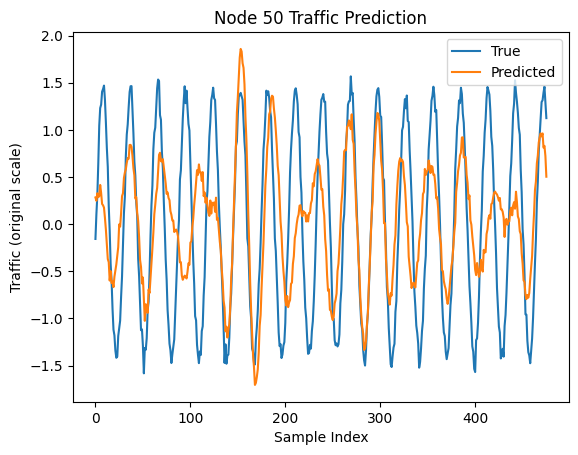

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')X_tensor = torch.tensor(X, dtype=torch.float32).to(device)  Y_tensor = torch.tensor(Y, dtype=torch.float32).to(device)  A_norm = A_norm.to(device)  class STGCN(nn.Module):    def __init__(self, A, in_timesteps=24, temp_channels=12, gcn_hidden=12):        super(STGCN, self).__init__()        self.A = A          self.temp_conv = nn.Conv2d(1, temp_channels, kernel_size=(3,1), padding=(1,0))        self.bn = nn.BatchNorm2d(temp_channels)        self.gcn1 = nn.Linear(temp_channels, gcn_hidden)        self.gcn2 = nn.Linear(gcn_hidden, 1)    def forward(self, x):        b, T, N = x.shape        t = x.unsqueeze(1)                   t = self.temp_conv(t)                t = self.bn(t)        t = F.relu(t)        t = t.mean(dim=2)                    t = torch.einsum('ij,bkj->bki', self.A, t)          t = t.permute(0,2,1)                 t = self.gcn1(t)                     t = F.relu(t)        t = torch.einsum('ij,bkj->bki', self.A, t.permute(0,2,1))          t = t.permute(0,2,1)                 t = self.gcn2(t)                     t = t.squeeze(-1)                    return tlr = 0.008epochs = 300batch_size = 8dataset = TensorDataset(X_tensor, Y_tensor)loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)model = STGCN(A_norm).to(device)criterion = nn.MSELoss()optimizer = optim.Adam(model.parameters(), lr=lr)model.train()for epoch in range(epochs):    total_loss = 0.0    for xb, yb in loader:        optimizer.zero_grad()        preds = model(xb)        loss = criterion(preds, yb)        loss.backward()        optimizer.step()        total_loss += loss.item() * xb.size(0)    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataset):.4f}")model.eval()with torch.no_grad():    Y_pred = model(X_tensor).cpu().numpy()      Y_true = Y_tensor.cpu().numpy()    mse = np.mean((Y_pred - Y_true)**2)    print(f"Overall MSE: {mse:.4f}")signal_mean = signals.mean()signal_std = signals.std()true_node50 = Y_true[:,50] * signal_std + signal_meanpred_node50 = Y_pred[:,50] * signal_std + signal_meanplt.figure()plt.plot(true_node50, label='True')plt.plot(pred_node50, label='Predicted')plt.title('Node 50 Traffic Prediction')plt.xlabel('Sample Index')plt.ylabel('Traffic (original scale)')plt.legend()plt.show()

Analysis:Looking at the plot, the model mostly learns the daily traffic cycle—its orange line goes up and down at the same times as the real blue line. But it does make some consistent mistakes:Flattened peaks and dips: The biggest traffic jams and the quietest times are too “smoothed out.” The model never predicts quite as high or as low as it should.Timing slips: A few times (around samples 100–120 and 300–320) the orange line is a bit early or late compared to the blue one.Overreacting to an outlier: Near index 150 there’s a spike that the model actually overshoots—it predicts a bigger jump than really happened.The lines match pretty well in shape, which means the STGCN’s basic idea is working. To fix the problems with extreme values, we could try making the model deeper (more layers or extra shortcut connections) or use a loss that cares more about big errors so it learns to hit those peaks and valleys better. But I have to study for DL final.